In [4]:
#importamos librerias
import pandas as pd
from scipy import stats as stats
import matplotlib.pyplot as plt
import datetime
import numpy as np
import seaborn as sns

# Cargar y preparar los datos para el analisis


In [6]:
visits = pd.read_csv('/content/sample_data/visits_log_us.csv')
orders = pd.read_csv('/content/sample_data/orders_log_us.csv')
costs = pd.read_csv('/content/sample_data/costs_us.csv')

## Tabla 'visits'

In [7]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [8]:
# Cambio de formato al nombre de las columnas
columns_new = []
for column in visits.columns:
  column_new = column.lower().replace(' ', '_')
  columns_new.append(column_new)

visits.columns = columns_new

visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   device     359400 non-null  object
 1   end_ts     359400 non-null  object
 2   source_id  359400 non-null  int64 
 3   start_ts   359400 non-null  object
 4   uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [9]:
# cambio de tipo de datos para las columnas 'end_ts' y 'start_ts' a tipo datetime64

visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])


In [10]:
print('Filas duplicadas:', visits.duplicated().sum())

Filas duplicadas: 0


No se encontraron filas duplicadas o vacias en el dataset 'visits'.


## Tabla 'orders'

In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [12]:
#cambio de formato al nombre de las columnas

columns_new = []

for column in orders.columns:
  column_new = column.lower().replace(' ', '_')
  columns_new.append(column_new)

orders.columns = columns_new

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [13]:
# cambio de tipo de datos a la columna 'buy_ts' a tipo de datetime64

orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [14]:
print('Filas duplicadas:', orders.duplicated().sum())

Filas duplicadas: 0


In [15]:
print(orders['buy_ts'].sort_values(ascending=False))

#solo hay una orden para junio 2018, carece de relevancia, lo excluiremos del analisis
orders.drop(orders.index[-1], inplace=True)
print(orders['buy_ts'].max())

50414   2018-06-01 00:02:00
50413   2018-05-31 23:56:00
50412   2018-05-31 23:54:00
50411   2018-05-31 23:50:00
50410   2018-05-31 23:50:00
                ...        
4       2017-06-01 07:58:00
3       2017-06-01 00:29:00
2       2017-06-01 00:27:00
1       2017-06-01 00:25:00
0       2017-06-01 00:10:00
Name: buy_ts, Length: 50415, dtype: datetime64[ns]
2018-05-31 23:56:00


No se encontraron filas duplicadas o vacias para el dataset 'orders'

## Tabla 'costs'

In [16]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [17]:
# cambio de tipo de dato para la columna 'dt' a tipo de dato datetime64

costs['dt'] = pd.to_datetime(costs['dt'])

costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


In [18]:
print('Filas duplicadas:', costs.duplicated().sum())

Filas duplicadas: 0


No se encontraron filas duplicadas o vacias en el dataset 'costs'

# Informes y cálculo de métricas

## Metricas de Usuario

In [19]:
# cuantas personas lo usan cada dia, semana y mes
visits['date'] = pd.to_datetime(visits['start_ts'].dt.date)
visits['week'] = visits['date'] - pd.to_timedelta(visits['date'].dt.dayofweek, unit='d')
visits['month'] = visits['date'] - pd.to_timedelta(visits['date'].dt.day, unit='d') + pd.to_timedelta(1, unit='d')
print(visits[['date', 'week', 'month']].head(10))

        date       week      month
0 2017-12-20 2017-12-18 2017-12-01
1 2018-02-19 2018-02-19 2018-02-01
2 2017-07-01 2017-06-26 2017-07-01
3 2018-05-20 2018-05-14 2018-05-01
4 2017-12-27 2017-12-25 2017-12-01
5 2017-09-03 2017-08-28 2017-09-01
6 2018-01-30 2018-01-29 2018-01-01
7 2017-11-05 2017-10-30 2017-11-01
8 2017-07-19 2017-07-17 2017-07-01
9 2017-11-08 2017-11-06 2017-11-01


In [20]:
users_per_day = visits.groupby('date').agg({'uid': 'nunique'}).reset_index()
users_per_week = visits.groupby('week').agg({'uid': 'nunique'}).reset_index()
users_per_month = visits.groupby('month').agg({'uid': 'nunique'}).reset_index()

dau_total = users_per_day['uid'].mean()
wau_total = users_per_week['uid'].mean()
mau_total = users_per_month['uid'].mean()

print('DAU promedio:', dau_total)
print('WAU promedio:', wau_total)
print('MAU promedio:', mau_total)

DAU promedio: 907.9917582417582
WAU promedio: 5716.245283018868
MAU promedio: 23228.416666666668


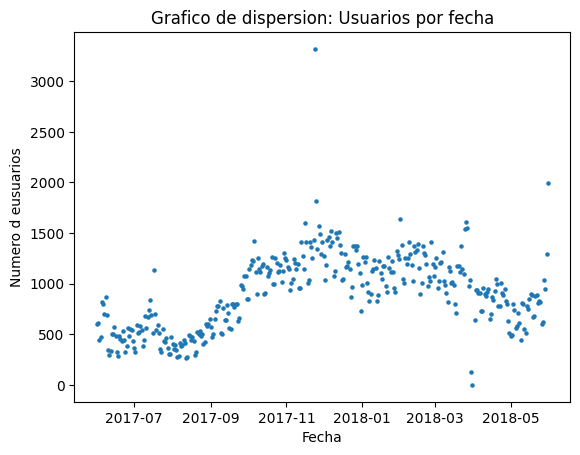

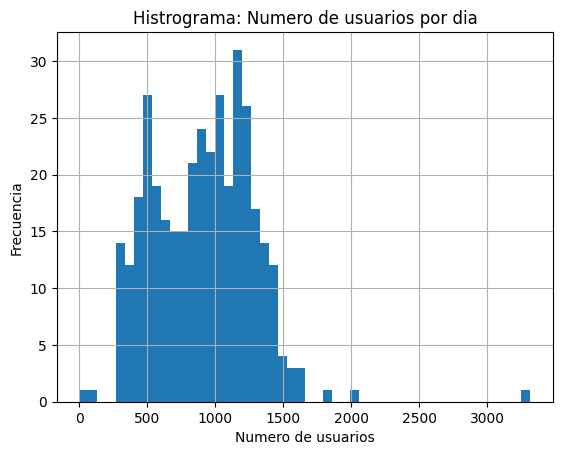

In [21]:
users_per_day.plot(kind='scatter', x='date', y='uid', marker='.')
plt.title('Grafico de dispersion: Usuarios por fecha')
plt.xlabel('Fecha')
plt.ylabel('Numero d eusuarios')
plt.show()

users_per_day['uid'].hist(bins = 50)
plt.title('Histrograma: Numero de usuarios por dia')
plt.xlabel('Numero de usuarios')
plt.ylabel('Frecuencia')
plt.show()

In [22]:
# cuantas sesiones hay por dia

sessions_per_day = visits.groupby('date').agg({'uid': ['count', 'nunique']}).reset_index()
sessions_per_day.columns = ['date', 'n_sessions', 'n_users']

sessions_per_day['sessions_per_user'] = sessions_per_day['n_sessions'] / sessions_per_day['n_users']

print(sessions_per_day)
print('Sesiones promedio por usuario:', sessions_per_day['sessions_per_user'].mean())

          date  n_sessions  n_users  sessions_per_user
0   2017-06-01         664      605           1.097521
1   2017-06-02         658      608           1.082237
2   2017-06-03         477      445           1.071910
3   2017-06-04         510      476           1.071429
4   2017-06-05         893      820           1.089024
..         ...         ...      ...                ...
359 2018-05-27         672      620           1.083871
360 2018-05-28        1156     1039           1.112608
361 2018-05-29        1035      948           1.091772
362 2018-05-30        1410     1289           1.093871
363 2018-05-31        2256     1997           1.129695

[364 rows x 4 columns]
Sesiones promedio por usuario: 1.082169644003972


En promedio, los usuarios tienen poco más de una sesión al día: 1.08 sesiones promedio diarias.

In [23]:
#Duracion promedio de la sesion

visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

print('Duracion promedio de sesion en segundos:', visits['session_duration'].mean())
print('Duracion promedio de sesion en minutos:', visits['session_duration'].mean() / 60)

Duracion promedio de sesion en segundos: 643.506488592098
Duracion promedio de sesion en minutos: 10.725108143201632


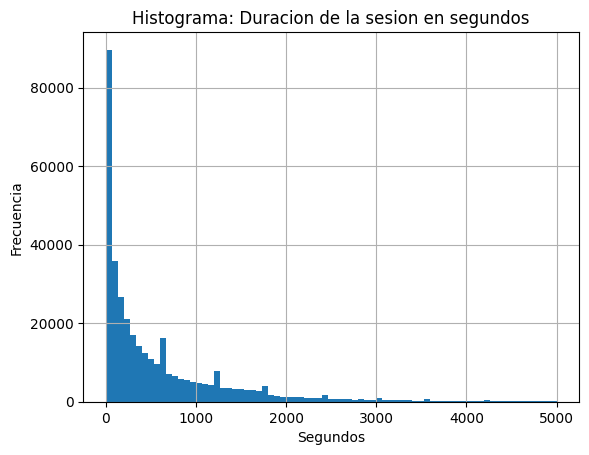

In [24]:
visits['session_duration'].hist(bins=75, range=(0, 5000))
plt.title('Histograma: Duracion de la sesion en segundos')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.show()

Al no contar con una distribucion normal o similar, tomaremos la moda como valor de la duracion media.



In [25]:
print('Duracion media usando la moda (ASL):', visits['session_duration'].mode()[0], 'segundos')

Duracion media usando la moda (ASL): 60 segundos


In [26]:
# con que frecuencia regresan los usuarios

weekly_sticky_factor = dau_total / wau_total * 100
monthly_sticky_factor = dau_total / mau_total * 100

print('Factor de adherencia semanal:', weekly_sticky_factor, '%')
print('Factor de adherencia mensual:', monthly_sticky_factor, '%')

Factor de adherencia semanal: 15.88440861589881 %
Factor de adherencia mensual: 3.908969652437603 %


Contamos con un factor de adherencia semanal decente de 15.88%, comparativamente el factor de adherencia mensual es relativamente bajo con 3.91%, lo que nos inclina a pensar que hay un poco compromiso por parte de los usuarios. Es necesario tomar acción para subir el factor de adherencia.

La duration promedio de la sesión es de a penas 1 minuto, esto puede significar que o la aplicación está muy bien diseñada, es fácil de usar y por ende los usuarios no requieren más de un minuto en realizar sus pedidos, o, por el contrario, la app es abrumadora para el usuario promedio y sale de la aplicación después de 60 segundos.

## Metricas de Compras


In [27]:
#Cuando empieza la gente a comprar

#buscamos la primera visita por cliente
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit']

print(first_visit)

                         uid         first_visit
0             11863502262781 2018-03-01 17:27:00
1             49537067089222 2018-02-06 15:55:00
2            297729379853735 2017-06-07 18:47:00
3            313578113262317 2017-09-18 22:49:00
4            325320750514679 2017-09-30 14:29:00
...                      ...                 ...
228164  18446403737806311543 2017-11-30 03:36:00
228165  18446424184725333426 2017-12-06 20:32:00
228166  18446556406699109058 2018-01-01 16:29:00
228167  18446621818809592527 2017-12-27 13:27:00
228168  18446676030785672386 2017-10-04 16:01:00

[228169 rows x 2 columns]


In [28]:
#buscamos la primera orden por cliente
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order']

print(first_order)

                        uid         first_order
0           313578113262317 2018-01-03 21:51:00
1          1575281904278712 2017-06-03 10:13:00
2          2429014661409475 2017-10-11 18:33:00
3          2464366381792757 2018-01-28 15:54:00
4          2551852515556206 2017-11-24 10:14:00
...                     ...                 ...
36517  18445147675727495770 2017-11-24 09:03:00
36518  18445407535914413204 2017-09-22 23:55:00
36519  18445601152732270159 2018-03-26 22:54:00
36520  18446156210226471712 2018-02-18 19:34:00
36521  18446167067214817906 2017-10-17 10:16:00

[36522 rows x 2 columns]


In [29]:
#unimos nuestros datos de primera visita y primera compra
conversion = first_visit.merge(first_order, on='uid', how='inner')
conversion['days_to_conversion'] = (conversion['first_order'] - conversion['first_visit']).dt.days
print(conversion)

                        uid         first_visit         first_order  \
0           313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1          1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2          2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3          2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4          2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   
...                     ...                 ...                 ...   
36517  18445147675727495770 2017-08-20 13:30:00 2017-11-24 09:03:00   
36518  18445407535914413204 2017-09-22 23:48:00 2017-09-22 23:55:00   
36519  18445601152732270159 2017-08-07 11:51:00 2018-03-26 22:54:00   
36520  18446156210226471712 2017-11-07 10:01:00 2018-02-18 19:34:00   
36521  18446167067214817906 2017-10-17 10:05:00 2017-10-17 10:16:00   

       days_to_conversion  
0                     106  
1                       0  
2                       0  
3                       0  
4      

In [30]:
#Categorizamos los dias que tardaron en ordenar
def cat_conversion(days):
  if days < 0:
    return 'Negative'
  elif days == 0:
    return 'Conversion 0d'
  elif days == 1:
    return 'Conversion 1d'
  elif days <=7:
    return 'Converison 1-7d'
  elif days <=30:
    return 'Conversion 8-30d'
  else:
    return 'Conversion +30d'


conversion['category'] = conversion['days_to_conversion'].apply(cat_conversion)

print(conversion)

                        uid         first_visit         first_order  \
0           313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1          1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2          2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3          2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4          2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   
...                     ...                 ...                 ...   
36517  18445147675727495770 2017-08-20 13:30:00 2017-11-24 09:03:00   
36518  18445407535914413204 2017-09-22 23:48:00 2017-09-22 23:55:00   
36519  18445601152732270159 2017-08-07 11:51:00 2018-03-26 22:54:00   
36520  18446156210226471712 2017-11-07 10:01:00 2018-02-18 19:34:00   
36521  18446167067214817906 2017-10-17 10:05:00 2017-10-17 10:16:00   

       days_to_conversion         category  
0                     106  Conversion +30d  
1                       0    Conversion 0d  
2           

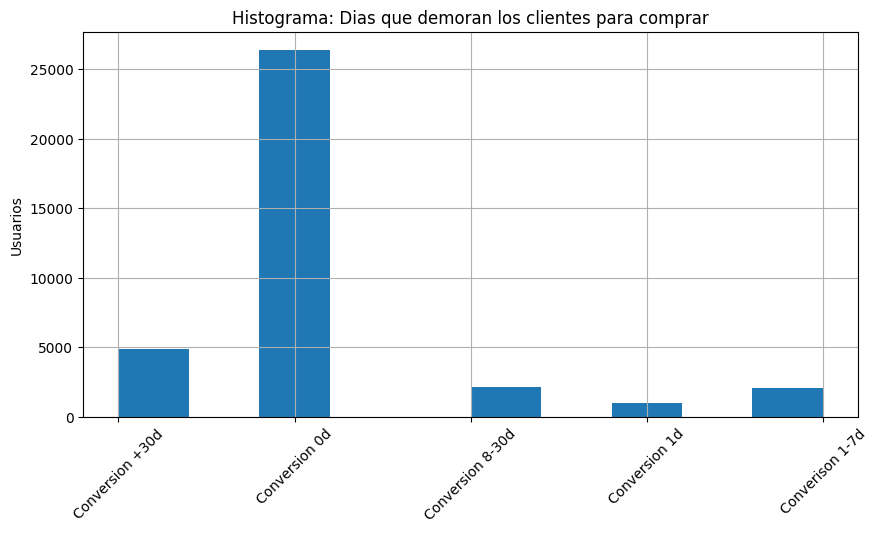

In [31]:
#Mostramos el resultado de la categorizacion
conversion['category'].hist(figsize=(10, 5))
plt.xticks(rotation=45)
plt.title('Histograma: Dias que demoran los clientes para comprar')
plt.ylabel('Usuarios')
plt.show()


En el histograma podemos apreciar que el número de veces que los clientes realizan su primera compra el mismo día de su primera visita es casi 5 veces más que la segunda barra, que corresponde a las veces que los clientes realizan su primera compra más de 30 días después de su primera sesión, es congruente con la métrica del factor de adherencia mensual que calculamos anteriormente, necesitamos reducir los días de conversión de los usuarios.

In [32]:
# Cuantos pedidos hacen durante un periodo de tiempo dado
# creamos una nueva columna con los meses de compra
orders['order_month'] = orders['buy_ts'].dt.date - pd.to_timedelta(orders['buy_ts'].dt.day, unit='d') + pd.to_timedelta(1, unit='d')

/tmp/ipython-input-1201609114.py:3: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  orders['order_month'] = orders['buy_ts'].dt.date - pd.to_timedelta(orders['buy_ts'].dt.day, unit='d') + pd.to_timedelta(1, unit='d')


In [33]:
info_per_month = orders.groupby('order_month').agg({'uid': ['count', 'nunique']}).reset_index()
info_per_month.columns = ['order_month', 'n_orders', 'n_buyers']
print(info_per_month)

   order_month  n_orders  n_buyers
0   2017-06-01      2354      2023
1   2017-07-01      2363      1984
2   2017-08-01      1807      1472
3   2017-09-01      3387      2750
4   2017-10-01      5679      4675
5   2017-11-01      5659      4547
6   2017-12-01      6218      4942
7   2018-01-01      4721      3898
8   2018-02-01      5281      4258
9   2018-03-01      5326      4181
10  2018-04-01      3273      2744
11  2018-05-01      4346      3544


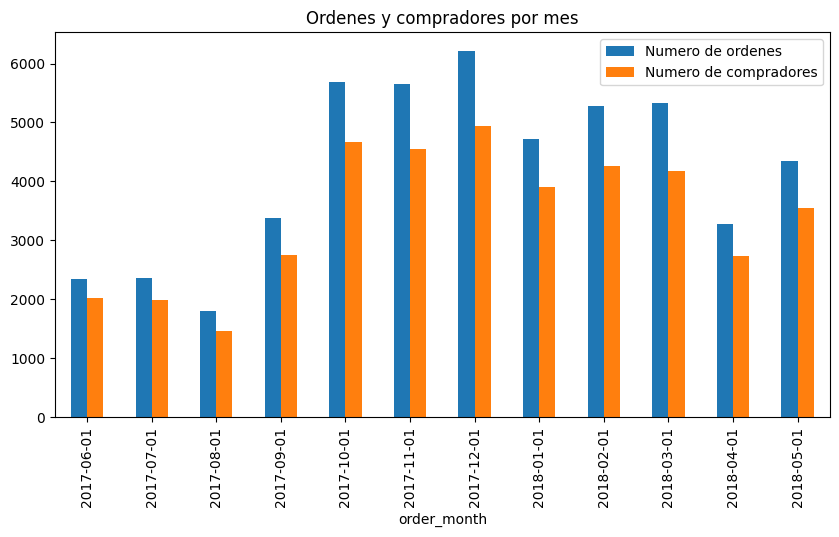

In [34]:
info_per_month.plot(x='order_month', y=['n_orders', 'n_buyers'], kind='bar', figsize=(10, 5))
plt.legend(['Numero de ordenes', 'Numero de compradores'])
plt.title('Ordenes y compradores por mes')
plt.show()


In [35]:
#Añadimos la fecha de primera compra a cada cliente a la tabla 'orders'
orders = orders.merge(first_order, on='uid')

In [36]:
#Agregamos la columna 'frist_order_month' con el mes d ela primera compra
orders['first_order_month'] = orders['first_order'].dt.date - pd.to_timedelta(orders['first_order'].dt.day, unit='d') + pd.to_timedelta(1, unit='d')

#agrupamos por cohortes la tabla 'orders'
cohort_orders = orders.groupby(['first_order_month', 'order_month']).size().unstack(fill_value=0)

print('Ordenes por cohortes:\n')
print(cohort_orders)

/tmp/ipython-input-2783944434.py:2: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  orders['first_order_month'] = orders['first_order'].dt.date - pd.to_timedelta(orders['first_order'].dt.day, unit='d') + pd.to_timedelta(1, unit='d')


Ordenes por cohortes:

order_month        2017-06-01  2017-07-01  2017-08-01  2017-09-01  2017-10-01  \
first_order_month                                                               
2017-06-01               2354         177         174         226         292   
2017-07-01                  0        2186         100         120         104   
2017-08-01                  0           0        1533         108         100   
2017-09-01                  0           0           0        2933         219   
2017-10-01                  0           0           0           0        4964   
2017-11-01                  0           0           0           0           0   
2017-12-01                  0           0           0           0           0   
2018-01-01                  0           0           0           0           0   
2018-02-01                  0           0           0           0           0   
2018-03-01                  0           0           0           0           0   
2018-

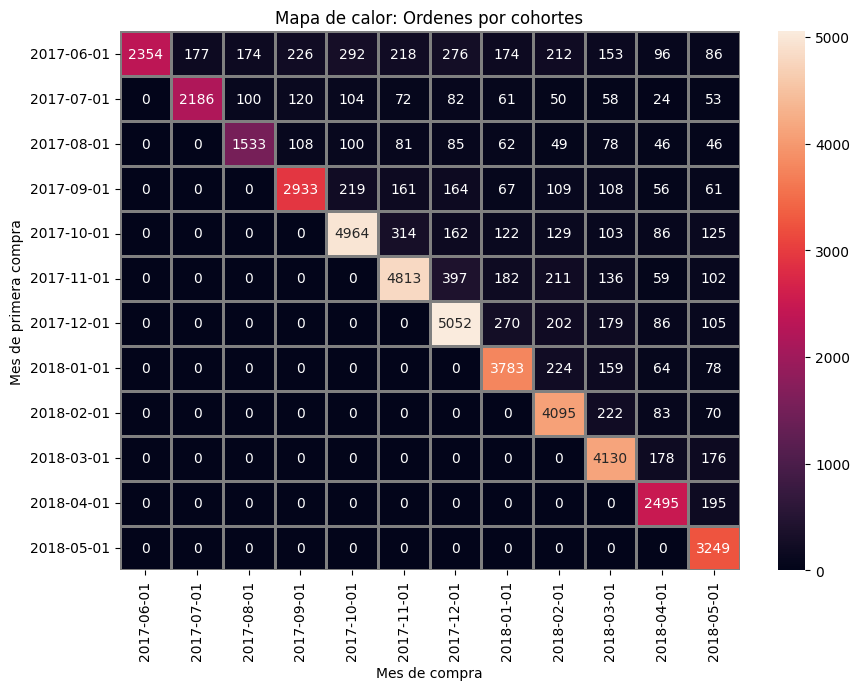

In [37]:
#mapa de calor
plt.figure(figsize=(10, 7))
sns.heatmap(cohort_orders,
            annot=True,
            linewidths=1,
            linecolor='gray',
            fmt='d')
plt.title('Mapa de calor: Ordenes por cohortes')
plt.xlabel('Mes de compra')
plt.ylabel('Mes de primera compra')
plt.show()



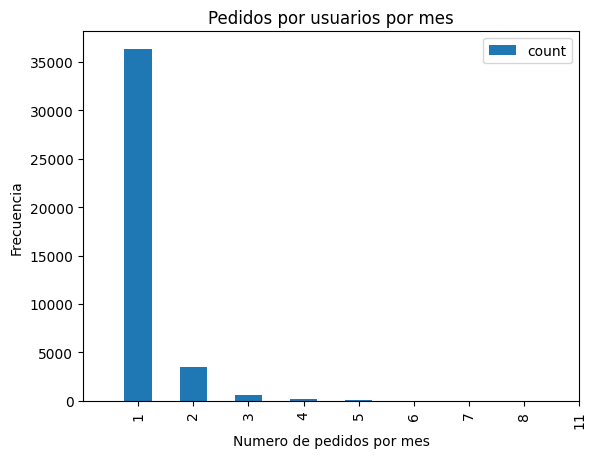

In [38]:
#pedidos por usuarios por mes
orders_per_user_per_month = orders.groupby(['uid', 'order_month']).size().reset_index(name='n_orders')

orders_per_user_per_month['n_orders'].value_counts().reset_index().plot(x='n_orders', y='count', kind='bar')
plt.xlim(-1, 8)
plt.xlabel('Numero de pedidos por mes')
plt.ylabel('Frecuencia')
plt.title('Pedidos por usuarios por mes')
plt.show()


In [39]:
# cual es el tamano promedio de compra

# calculamos el ingreso promedio por usuario para cada mes
#agrupamos los datos por cohhortes y por mes de compra

orders_by_cohort = orders.groupby(['first_order_month', 'order_month']).agg({'revenue': 'sum', 'uid': 'nunique'}).reset_index()
orders_by_cohort.columns = ['first_order_month', 'order_month', 'total_revenue', 'n_users']

#agregamos la columna 'revenue_per_user' el ingreso promedio por usuario
orders_by_cohort['revenue_per_user'] = orders_by_cohort['total_revenue'] / orders_by_cohort['n_users']

#mostramos una tabla dinamica con los cambios por cohortes de los ingresos promedio de los usuarios
print('Ingreso promedio por cliente, por cohortes:')
print(orders_by_cohort.pivot_table(
    index='first_order_month',
    columns='order_month',
    values='revenue_per_user',
    aggfunc='mean'
).fillna(''))

Ingreso promedio por cliente, por cohortes:
order_month       2017-06-01 2017-07-01 2017-08-01 2017-09-01 2017-10-01  \
first_order_month                                                          
2017-06-01          4.724414   16.09541    17.7068  35.764815  23.506591   
2017-07-01                     6.010218  12.396346  21.035965  10.786094   
2017-08-01                                5.276518  11.148793  11.851321   
2017-09-01                                           5.644529  22.188385   
2017-10-01                                                      5.003733   
2017-11-01                                                                 
2017-12-01                                                                 
2018-01-01                                                                 
2018-02-01                                                                 
2018-03-01                                                                 
2018-04-01                                  

In [40]:
#ciclo de vida de los cohortes
orders_by_cohort['cohort_lifetime'] = ((orders_by_cohort['order_month']
                                       - orders_by_cohort['first_order_month']) / (pd.Timedelta(days=1) * 30)).round().astype('int')


print(orders_by_cohort)

   first_order_month order_month  total_revenue  n_users  revenue_per_user  \
0         2017-06-01  2017-06-01        9557.49     2023          4.724414   
1         2017-06-01  2017-07-01         981.82       61         16.095410   
2         2017-06-01  2017-08-01         885.34       50         17.706800   
3         2017-06-01  2017-09-01        1931.30       54         35.764815   
4         2017-06-01  2017-10-01        2068.58       88         23.506591   
..               ...         ...            ...      ...               ...   
73        2018-03-01  2018-04-01        1063.05       90         11.811667   
74        2018-03-01  2018-05-01        1114.87       58         19.221897   
75        2018-04-01  2018-04-01       10600.69     2276          4.657597   
76        2018-04-01  2018-05-01        1209.92       69         17.535072   
77        2018-05-01  2018-05-01       13925.76     2988          4.660562   

    cohort_lifetime  
0                 0  
1                 1

In [41]:
# tamano promedio de compra
revenue_per_user_pivot = orders_by_cohort.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='revenue_per_user',
    aggfunc='mean'
)

print(revenue_per_user_pivot.fillna(''))

cohort_lifetime          0          1          2           3          4   \
first_order_month                                                          
2017-06-01         4.724414   16.09541    17.7068   35.764815  23.506591   
2017-07-01         6.010218  12.396346  21.035965   10.786094   6.938163   
2017-08-01         5.276518  11.148793  11.851321   12.182955   16.92125   
2017-09-01         5.644529  22.188385    13.4452  138.669189  19.881538   
2017-10-01         5.003733  11.287427   6.753252    7.413152   7.072796   
2017-11-01         5.154683   7.339054   6.786583    12.51066   7.457284   
2017-12-01         4.738191   7.816575  39.366019   48.135052    27.4314   
2018-01-01         4.135636   8.721228  12.365542   11.199767   4.699556   
2018-02-01         4.156987       8.61   4.942414    6.941026              
2018-03-01         4.838803  11.811667  19.221897                          
2018-04-01         4.657597  17.535072                                     
2018-05-01  

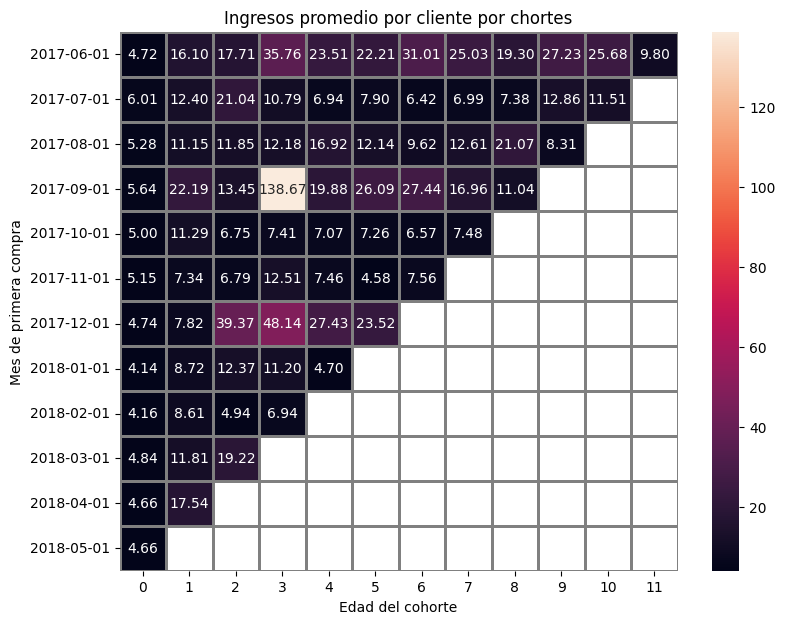

In [42]:
plt.figure(figsize=(9, 7))
sns.heatmap(revenue_per_user_pivot,
            annot=True,
            linewidths=1,
            linecolor='gray',
            fmt='.2f')
plt.title('Ingresos promedio por cliente por chortes')
plt.xlabel('Edad del cohorte')
plt.ylabel('Mes de primera compra')
plt.show()

In [45]:
# ltv promedio por cohorte

#creamos cohortes por mes de primera compra
first_visit['cohort_month'] = first_visit['first_visit'].dt.to_period('M')

#clientes por cohorte (mes de primer compra)
print('Clientes por chorte:\n', first_visit.groupby('cohort_month')['uid'].nunique())


Clientes por chorte:
 cohort_month
2017-06    13259
2017-07    13140
2017-08    10181
2017-09    16704
2017-10    25977
2017-11    27248
2017-12    25268
2018-01    22624
2018-02    22197
2018-03    20589
2018-04    15709
2018-05    15273
Freq: M, Name: uid, dtype: int64


In [46]:
#unimos los cohortes con las ordenes
orders_with_cohorts = orders.merge(first_visit, on='uid', how='left')

#ganancia por cohorte
print('Ganancia por cohorte:\n', orders_with_cohorts.groupby('cohort_month')['revenue'].sum())

Ganancia por cohorte:
 cohort_month
2017-06    40026.05
2017-07    17812.11
2017-08    13461.87
2017-09    33682.56
2017-10    27857.69
2017-11    24426.72
2017-12    31157.85
2018-01    14546.82
2018-02    15061.29
2018-03    13770.16
2018-04     9882.55
2018-05    10368.11
Freq: M, Name: revenue, dtype: float64


In [59]:
#ltv promedio por cohorte
ltv_by_cohort = (orders_with_cohorts.groupby('cohort_month')['revenue'].sum() /
                 first_visit.groupby('cohort_month')['uid'].nunique()).reset_index()
ltv_by_cohort.columns = ['cohort_month', 'avg_ltv']

print('LTV promedio por cohorte:\n', ltv_by_cohort)

LTV promedio por cohorte:
    cohort_month   avg_ltv
0       2017-06  3.018783
1       2017-07  1.355564
2       2017-08  1.322254
3       2017-09  2.016437
4       2017-10  1.072398
5       2017-11  0.896459
6       2017-12  1.233095
7       2018-01  0.642982
8       2018-02  0.678528
9       2018-03  0.668812
10      2018-04  0.629101
11      2018-05  0.678852


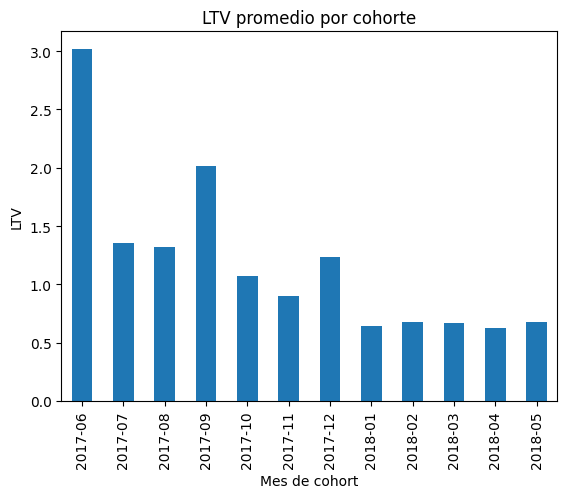

In [66]:
ltv_by_cohort.plot(x='cohort_month', y='avg_ltv', kind='bar')
plt.title('LTV promedio por cohorte')
plt.xlabel('Mes de cohort')
plt.ylabel('LTV')
plt.legend('', frameon=False)
plt.show()

El LTV promedio por cohorte cae progresivamente y, aunque sube ocasionalmente en las cohortes posteriores, continúa disminuyendo y oscila en un valor alrededor de 0.68.

## Metricas de marketing

In [57]:
#cuanto dinero se gasto
costs['month'] = costs['dt'].dt.to_period('M')
monthly_costs = costs.pivot_table(
    index='source_id',
    columns='month',
    values='costs',
    aggfunc='sum'
)
print('Costos por mes por fuente:\n', monthly_costs)

Costos por mes por fuente:
 month      2017-06  2017-07  2017-08  2017-09   2017-10   2017-11   2017-12  \
source_id                                                                     
1          1125.61  1072.88   951.81  1502.01   2315.75   2445.16   2341.20   
2          2427.38  2333.11  1811.05  2985.66   4845.00   5247.68   4897.80   
3          7731.65  7674.37  6143.54  9963.55  15737.24  17025.34  16219.52   
4          3514.80  3529.73  3217.36  5192.26   6420.84   5388.82   7680.47   
5          2616.12  2998.14  2185.28  3849.14   5767.40   6325.34   5872.52   
9           285.22   302.54   248.93   415.62    609.41    683.18    657.98   
10          314.22   329.82   232.57   460.67    627.24    792.36    645.86   

month       2018-01   2018-02   2018-03  2018-04  2018-05  
source_id                                                  
1           2186.18   2204.48   1893.09  1327.49  1467.61  
2           4157.74   4474.34   3943.14  2993.70  2689.44  
3          14808.78 

In [67]:
#costos totales por fuente de marketing
costs_by_source = costs.groupby('source_id')['costs'].sum()
print(costs_by_source)

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


In [70]:
#unimos visits y orders para sabqe que usuarios compraron
buyers = visits.merge(orders[['uid']], on='uid', how='inner')

#usuarios unicos por fuente
unique_buyers_by_source = buyers.groupby('source_id')['uid'].nunique()

print(unique_buyers_by_source)

source_id
1      7138
2      7305
3     13846
4     14252
5     10156
7         1
9      2793
10     1773
Name: uid, dtype: int64
0        2018-05-01
1        2017-09-01
2        2017-09-01
3        2017-09-01
4        2018-02-01
            ...    
761801   2018-01-01
761802   2018-01-01
761803   2018-03-01
761804   2017-11-01
761805   2017-09-01
Name: month, Length: 761806, dtype: datetime64[ns]


In [69]:
#costo de adquisicion de clientes de cada una de las fuentes
cac_by_source = costs_by_source / unique_buyers_by_source
cac_by_source.dropna(inplace=True)

print('CAC por fuente:\n', cac_by_source)

CAC por fuente:
 source_id
1      2.918642
2      5.859828
3     10.206676
4      4.285265
5      5.096209
9      1.975471
10     3.283976
dtype: float64


In [72]:
buyers['month'] = buyers['month'].dt.to_period('M')

In [74]:
# compradores mensuales
monthly_buyers = buyers.pivot_table(
    index='source_id',
    columns='month',
    values='uid',
    aggfunc='nunique'
)

#no hay informacion relevante para el analisis de la fuente con id 7
monthly_buyers.drop(index=7, inplace=True)


print(monthly_buyers)

month      2017-06  2017-07  2017-08  2017-09  2017-10  2017-11  2017-12  \
source_id                                                                  
1            406.0    437.0    332.0    594.0    911.0   1161.0   1158.0   
2            513.0    550.0    393.0    685.0   1114.0   1322.0   1268.0   
3            963.0    823.0    597.0   1238.0   1806.0   1951.0   1935.0   
4            735.0    861.0    604.0   1050.0   1985.0   2275.0   2391.0   
5            594.0    674.0    566.0    972.0   1489.0   1148.0   1293.0   
9            179.0    162.0    210.0    254.0    365.0    547.0    422.0   
10           128.0     75.0     59.0    115.0    268.0    215.0    120.0   

month      2018-01  2018-02  2018-03  2018-04  2018-05  
source_id                                               
1            848.0    841.0    915.0    557.0    662.0  
2           1008.0   1024.0   1046.0    725.0    974.0  
3           1602.0   1596.0   1450.0    992.0   1166.0  
4           1895.0   1911.0   

In [75]:
# CAC mensual por fuente
monthly_cac = (monthly_costs / monthly_buyers)

print('CAC mensual por fuente:\n', monthly_cac)

CAC mensual por fuente:
 month       2017-06   2017-07    2017-08   2017-09   2017-10   2017-11  \
source_id                                                                
1          2.772438  2.455103   2.866898  2.528636  2.541987  2.106081   
2          4.731735  4.242018   4.608270  4.358628  4.349192  3.969501   
3          8.028712  9.324872  10.290687  8.048102  8.713865  8.726468   
4          4.782041  4.099570   5.326755  4.945010  3.234680  2.368712   
5          4.404242  4.448279   3.860919  3.960021  3.873338  5.509878   
9          1.593408  1.867531   1.185381  1.636299  1.669616  1.248958   
10         2.454844  4.397600   3.941864  4.005826  2.340448  3.685395   

month       2017-12   2018-01   2018-02   2018-03   2018-04   2018-05  
source_id                                                              
1          2.021762  2.578042  2.621260  2.068951  2.383285  2.216934  
2          3.862618  4.124742  4.369473  3.769732  4.129241  2.761232  
3          8.382181 

In [76]:
orders_ = orders.merge(visits[['source_id', 'uid']], on='uid', how='inner').drop_duplicates()
orders_['month'] = orders_['buy_ts'].dt.to_period('M')

In [78]:
#calculamos el ingreso por mes de cada fuente
monthly_revenue = orders_.pivot_table(
    index='source_id',
    columns='month',
    values='revenue',
    aggfunc='sum'
)
monthly_revenue.dropna(inplace=True)
print('Ingreso mensual de cada fuente:\n', monthly_revenue)

Ingreso mensual de cada fuente:
 month      2017-06  2017-07  2017-08  2017-09   2017-10   2017-11   2017-12  \
source_id                                                                     
1          2563.84  3947.25  3325.64  8193.42  11466.14  11528.95  18814.15   
2          3161.11  4537.73  3051.20  7932.36  11937.49  11776.17  19801.66   
3          4165.12  5257.28  3958.83  9883.38  12349.31  12698.96  21566.10   
4          3958.09  5741.15  3926.61  8806.22  11992.78  13280.51  22305.57   
5          3162.01  4769.00  3852.72  8367.57  10899.11   8971.46  20693.95   
9           752.06  1049.31  1087.33  1795.28   2441.27   2635.98   2183.09   
10          432.71   316.02   422.41   573.04    942.25    985.13    610.49   

month      2018-01   2018-02   2018-03  2018-04  2018-05  
source_id                                                 
1          7643.43   8896.29  10899.34  6847.43  7505.50  
2          7532.34  11647.90  14820.53  7768.84  9557.18  
3          9717.86 

In [82]:
#Calculamos el romi mensual
monthly_romi = (monthly_revenue - monthly_costs) / monthly_costs * 100


print('ROMI mensual por fuente [%]:\n', monthly_romi)

ROMI mensual por fuente [%]:
 month         2017-06     2017-07     2017-08     2017-09     2017-10  \
source_id                                                               
1          127.773385  267.911602  249.401666  445.497034  395.137213   
2           30.227241   94.492759   68.476850  165.681960  146.387822   
3          -46.128963  -31.495615  -35.561093   -0.804633  -21.528108   
4           12.612097   62.651251   22.044471   69.602832   86.778988   
5           20.866398   59.065287   76.303265  117.388040   88.977876   
9          163.677161  246.833477  336.801510  331.952264  300.595658   
10          37.709248   -4.184100   81.627037   24.392732   50.221606   

month         2017-11     2017-12     2018-01     2018-02     2018-03  \
source_id                                                               
1          371.500842  703.611396  249.624917  303.555033  475.743361   
2          124.407167  304.297031   81.164286  160.326663  275.856044   
3          -25.41141

In [87]:
monthly_romi_transposed = monthly_romi.T.reset_index()

print(monthly_romi_transposed)

source_id    month           1           2          3           4           5  \
0          2017-06  127.773385   30.227241 -46.128963   12.612097   20.866398   
1          2017-07  267.911602   94.492759 -31.495615   62.651251   59.065287   
2          2017-08  249.401666   68.476850 -35.561093   22.044471   76.303265   
3          2017-09  445.497034  165.681960  -0.804633   69.602832  117.388040   
4          2017-10  395.137213  146.387822 -21.528108   86.778988   88.977876   
5          2017-11  371.500842  124.407167 -25.411416  146.445604   41.833641   
6          2017-12  703.611396  304.297031  32.963861  190.419336  252.386199   
7          2018-01  249.624917   81.164286 -34.377714   58.421613   47.097656   
8          2018-02  303.555033  160.326663 -24.130973  103.204854  150.459546   
9          2018-03  475.743361  275.856044  -5.548034  103.902970  214.300979   
10         2018-04  415.817822  159.506297 -15.510159   88.649855  132.960313   
11         2018-05  411.4097

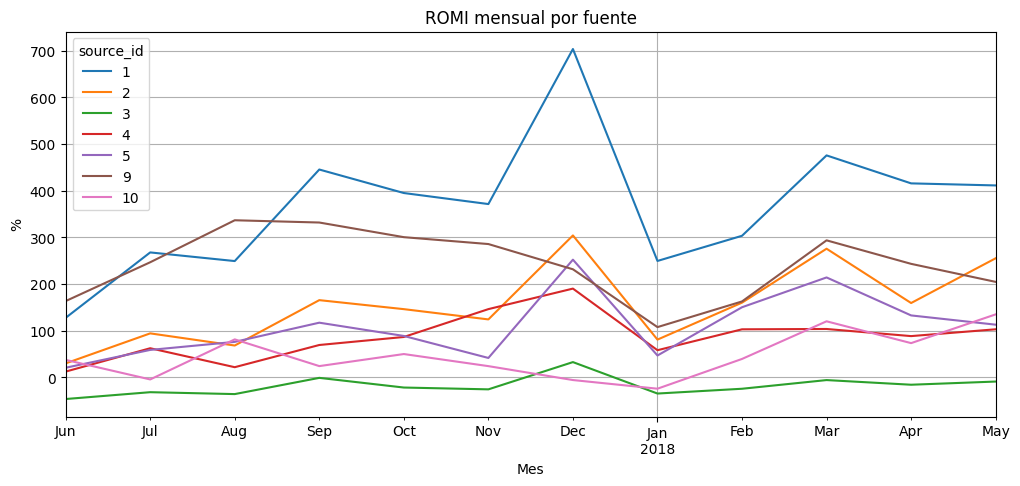

In [99]:
monthly_romi_transposed.plot(x='month', y=[1, 2, 3, 4, 5, 9, 10], figsize=(12, 5))
plt.title('ROMI mensual por fuente')
plt.xlabel('Mes')
plt.ylabel('%')
plt.grid(True)
plt.show()

Contamos con fuentes basándonos en el ROMI; se desempeñan bien. En el caso de la fuente con ID '1', alcanza hasta un 700% de ROMI y nunca baja de 100%.
Con excepción de la fuente con ID '3' todas las fuentes terminan en mayo 2018 con un ROMI mayor al 100%.
La fuente con ID '3' fracasa en casi todos los meses, con un desempeño negativo en 11 de 12 meses del análisis.
